# Agglomerative (Bottom-Up) Hierarchical Clustering — GED Candidates

- **Input:** exam-level data → aggregate to **candidate-level** (one row per candidate).
- **Two-stage completeness filter:** keep only candidates with ≥70% non-missing on 26 key fields; then drop those with no demographic identity (gender, race, ethnicity all missing).
- **Clustering features:** only 12 numeric features after variance (≥0.15) and correlation (|r|≤0.80) filtering; demographics excluded from clustering (used for post-hoc profiling only).
  - *Variance filter:* drop columns that hardly vary (everyone looks similar on that column — no discriminative power).
  - *Correlation filter:* for any pair of columns that are too similar (redundant), drop one so the remaining features are unlike each other.
- **Preprocessing:** continuous → z-score; non–subject-score NA → 0; subject scores keep NA for Gower; binary stay 0/1.
- **Distance:** Gower dissimilarity → **AgglomerativeClustering**(metric='precomputed', linkage='average').

In [58]:
!pip install gower

In [59]:
# ---------------------------------------------------------------------------
# 1. Imports, constants, load data
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import gower


INPUT_FILE = "/Users/ankit/Downloads/EDA-Team assignment/5_test_candidate_cleaned_final.csv"
VAR_THRESHOLD = 0.15
COR_THRESHOLD = 0.80
COMPLETENESS_THRESHOLD = 0.70
PROTECTED_CLUSTERING = "avg_score"

raw = pd.read_csv(INPUT_FILE)
print("Raw:", raw.shape[0], "rows x", raw.shape[1], "cols | Unique candidates:", raw["CANDIDATE_ID"].nunique())

Raw: 25657 rows x 60 cols | Unique candidates: 4691


In [60]:
# ---------------------------------------------------------------------------
# 2. Aggregate exam-level to candidate-level (one row per candidate)
# ---------------------------------------------------------------------------
raw = raw.copy()
raw["score_clean"] = np.where(raw["SCORE_MISSING"] == 1, np.nan, raw["SCORE"])

g = raw.groupby("CANDIDATE_ID")
candidates = pd.DataFrame(index=g.indices.keys()).reset_index(names="CANDIDATE_ID")

# Performance
candidates["avg_score"] = g["score_clean"].mean().values
candidates["total_attempts"] = g.size().values
candidates["pass_rate"] = g.apply(lambda x: np.nanmean((x["score_clean"].notna() & (x["score_clean"] >= 145)).astype(int))).values
candidates["college_ready_rate"] = g.apply(lambda x: np.nanmean((x["score_clean"].notna() & (x["score_clean"] >= 165)).astype(int))).values
candidates["avg_retakes"] = g["EXAM_SUBJECT"].apply(lambda x: x.size / x.nunique() - 1).values
candidates["credential_earned"] = g["CREDENTIAL_DATE"].apply(lambda s: 1 if s.notna().any() else 0).values

# Subject scores (Math=1, Science=2, Reasoning=3, Social Studies=4); NaN if never took that subject
for subj, name in [(1, "score_math"), (2, "score_science"), (3, "score_reasoning"), (4, "score_social_studies")]:
    candidates[name] = g.apply(lambda d, s=subj: d.loc[d["EXAM_SUBJECT"] == s, "score_clean"].mean()).values
# Delivery
candidates["pct_online"] = g["ON_VUE"].apply(lambda x: (x == 1).mean()).values
candidates["used_ged_ready"] = g["GED_READY"].apply(lambda x: 1 if (x == 1).any() else 0).values

# Preparation (first observation per candidate)
for col in ["STUDIED_FOR_GED", "TESTING_REASON", "SCHOOL_INCOMPLETE_REASON", "ENROLLMENT_STATUS",
            "STUDY_HELPFUL_ADULT_EDUCATION_CLASS", "STUDY_HELPFUL_BOOKS_PRINTED_STUDY_MATERIAL",
            "STUDY_HELPFUL_ONLINE_COURSE_VIDEO_STUDY_MATERIALS"]:
    candidates[col.lower()] = g[col].first().values
candidates["has_prep_center"] = (g["PREP_CENTER"].first() != "UNKNOWN").astype(int).values

# Demographics / geography (first) — not used in clustering, post-hoc only
for col in ["GENDER", "LANGUAGE_CODE", "LAST_YEAR_INCOME", "HIGHEST_GRADE_COMPLETED", "ETHNICITY",
            "WHITE", "AFRICAN_AMERICAN", "ASIAN", "INDIAN_OR_ALASKAN", "HAWAIIAN_OR_PACIFIC",
            "RACE_DECLINE", "RACE_NONE", "BIRTH_YEAR", "C_STATE"]:
    candidates[col.lower()] = g[col].first().values

candidates["age"] = 2024 - candidates["birth_year"]
print("Candidates after aggregation:", len(candidates))

/var/folders/3k/43d1tpsj0pq8dcfn0ky0mdlh0000gn/T/ipykernel_78944/4102110888.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates["pass_rate"] = g.apply(lambda x: np.nanmean((x["score_clean"].notna() & (x["score_clean"] >= 145)).astype(int))).values
/var/folders/3k/43d1tpsj0pq8dcfn0ky0mdlh0000gn/T/ipykernel_78944/4102110888.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates["college_r

Candidates after aggregation: 4691


/var/folders/3k/43d1tpsj0pq8dcfn0ky0mdlh0000gn/T/ipykernel_78944/4102110888.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates[name] = g.apply(lambda d, s=subj: d.loc[d["EXAM_SUBJECT"] == s, "score_clean"].mean()).values


In [61]:
# ---------------------------------------------------------------------------
# 3. Two-stage completeness filter 一共用这 26 列来算完整度，删完整度<70%的「行」（候选人）
# ---------------------------------------------------------------------------
# 26 key fields used for completeness (candidate kept only if >= 70% non-missing):
#   1. avg_score              — mean score across attempts
#   2. pass_rate              — share of attempts with score >= 145
#   3. college_ready_rate     — share of attempts with score >= 165
#   4. avg_retakes            — (attempts / distinct subjects) - 1
#   5. credential_earned      — 1 if CREDENTIAL_DATE present, else 0
#   6. pct_online             — share of attempts with ON_VUE == 1
#   7. used_ged_ready         — 1 if any GED_READY == 1, else 0
#   8. studied_for_ged        — first STUDIED_FOR_GED
#   9. has_prep_center        — 1 if PREP_CENTER != "UNKNOWN", else 0
#  10. study_helpful_adult_education_class  — first STUDY_HELPFUL_ADULT_EDUCATION_CLASS
#  11. study_books            — first STUDY_HELPFUL_BOOKS_PRINTED_STUDY_MATERIAL
#  12. study_helpful_online_course_video_study_materials — first (online/video study)
#  13. score_math             — mean score in Math (EXAM_SUBJECT==1); NaN if never took
#  14. score_science          — mean score in Science (2)
#  15. score_reasoning        — mean score in Reasoning (3)
#  16. score_social_studies    — mean score in Social Studies (4)
#  17. testing_reason         — first TESTING_REASON
#  18. school_incomplete_reason — first SCHOOL_INCOMPLETE_REASON
#  19. enrollment_status      — first ENROLLMENT_STATUS
#  20. gender_check           — gender with 0 (Unknown) treated as missing
#  21. income_check           — last_year_income with 0 treated as missing
#  22. grade_check            — highest_grade with 0 treated as missing
#  23. ethnicity_check        — ethnicity with 0 treated as missing
#  24. african_american       — first AFRICAN_AMERICAN
#  25. white                  — first WHITE
#  26. birth_year             — first BIRTH_YEAR
#
# Treat 0 as missing (unknown) for demographic sentinels
candidates["gender_check"] = candidates["gender"].replace(0, np.nan)
candidates["income_check"] = candidates["last_year_income"].replace(0, np.nan)
candidates["grade_check"] = candidates["highest_grade_completed"].replace(0, np.nan)
candidates["ethnicity_check"] = candidates["ethnicity"].replace(0, np.nan)

clustering_check_cols = [
    "avg_score", "pass_rate", "college_ready_rate", "avg_retakes",
    "credential_earned", "pct_online", "used_ged_ready", "studied_for_ged",
    "has_prep_center", "study_helpful_adult_education_class", "study_books",
    "study_helpful_online_course_video_study_materials",
    "score_math", "score_science", "score_reasoning", "score_social_studies",
    "testing_reason", "school_incomplete_reason", "enrollment_status",
    "gender_check", "income_check", "grade_check", "ethnicity_check",
    "african_american", "white", "birth_year",
]
clustering_check_cols = [c for c in clustering_check_cols if c in candidates.columns]

# Stage 1: keep only candidates with >= 70% non-missing on the 26 key fields
candidates["completeness"] = candidates[clustering_check_cols].notna().mean(axis=1)
n_before = len(candidates)
candidates = candidates[candidates["completeness"] >= COMPLETENESS_THRESHOLD].copy()
n_stage1 = n_before - len(candidates)

# Stage 2: drop if no demographic identity (gender, race, ethnicity all missing)
# Use the race indicator columns that actually exist (prevents KeyError if schema changes)
race_cols_all = ["african_american", "white", "asian", "indian_or_alaskan", "hawaiian_or_pacific"]
race_cols = [c for c in race_cols_all if c in candidates.columns]

if race_cols:
    no_race = (candidates[race_cols].fillna(0) == 0).all(axis=1)
else:
    # If race columns are absent, treat race identity as missing for everyone
    no_race = pd.Series(True, index=candidates.index)

no_gender = candidates["gender_check"].isna()
no_ethnicity = candidates["ethnicity_check"].isna()
drop_stage2 = no_gender & no_race & no_ethnicity
n_before2 = len(candidates)
candidates = candidates[~drop_stage2].copy()
n_stage2 = n_before2 - len(candidates)

print(f"Stage 1 (completeness >= {COMPLETENESS_THRESHOLD:.0%}): {n_stage1} removed")
print(f"Stage 2 (no demographic identity): {n_stage2} removed")
print(f"Retained: {len(candidates)} candidates")

Stage 1 (completeness >= 70%): 33 removed
Stage 2 (no demographic identity): 960 removed
Retained: 3698 candidates


In [62]:
# ---------------------------------------------------------------------------
# 4. Feature selection: variance filter, then correlation filter
# ---------------------------------------------------------------------------
# Only these 12 features are eligible for clustering (no study/reason/enrollment in R)
numeric_cols = [
    "avg_score", "pass_rate", "college_ready_rate", "avg_retakes",
    "credential_earned", "pct_online", "used_ged_ready", "has_prep_center",
    "score_math", "score_science", "score_reasoning", "score_social_studies",
]
numeric_cols = [c for c in numeric_cols if c in candidates.columns]

# Variance: relative variation = sd / |mean|; retain if >= VAR_THRESHOLD or protected
var_list = []
for feat in numeric_cols:
    x = candidates[feat].dropna()
    if len(x) == 0 or x.mean() == 0:
        rel_var = 0.0
    else:
        rel_var = x.std() / np.abs(x.mean())
    var_list.append({"feature": feat, "variance": rel_var, "retain": feat == PROTECTED_CLUSTERING or rel_var >= VAR_THRESHOLD})
var_df = pd.DataFrame(var_list)
retained_numeric = var_df[var_df["retain"]]["feature"].tolist()
print("After variance filter", retained_numeric)

# Correlation: drop one of each pair with |r| > COR_THRESHOLD (never drop avg_score)
numeric_for_cor = candidates[retained_numeric].select_dtypes(include=[np.number])
cor_matrix = numeric_for_cor.corr(method="pearson", min_periods=1)
cor_dropped = []
for i in range(len(retained_numeric)):
    for j in range(i + 1, len(retained_numeric)):
        a, b = retained_numeric[i], retained_numeric[j]
        if a in cor_dropped or b in cor_dropped:
            continue
        r = cor_matrix.loc[a, b]
        if np.abs(r) <= COR_THRESHOLD:
            continue
        if a == PROTECTED_CLUSTERING and b == PROTECTED_CLUSTERING:
            continue
        va = var_df.loc[var_df["feature"] == a, "variance"].iloc[0]
        vb = var_df.loc[var_df["feature"] == b, "variance"].iloc[0]
        drop_feat = b if (a == PROTECTED_CLUSTERING or (b != PROTECTED_CLUSTERING and va >= vb)) else a
        cor_dropped.append(drop_feat)
retained_numeric = [f for f in retained_numeric if f not in cor_dropped]
print("After correlation filter:", retained_numeric)

# Final retained 8 columns (used for clustering):
# avg_score, pass_rate, college_ready_rate, avg_retakes, credential_earned, pct_online, used_ged_ready, has_prep_center


After variance filter ['avg_score', 'pass_rate', 'college_ready_rate', 'avg_retakes', 'credential_earned', 'pct_online', 'used_ged_ready', 'has_prep_center']
After correlation filter: ['avg_score', 'pass_rate', 'college_ready_rate', 'avg_retakes', 'credential_earned', 'pct_online', 'used_ged_ready', 'has_prep_center']


In [63]:
# ---------------------------------------------------------------------------
# 5. Build clustering matrix: z-score continuous, NA handling, binary 0/1
# ---------------------------------------------------------------------------
binary_candidates = [
    "used_ged_ready", "studied_for_ged", "has_prep_center", "credential_earned",
    "study_helpful_adult_education_class", "study_books", "study_helpful_online_course_video_study_materials",
]
binary_cols = [c for c in binary_candidates if c in retained_numeric]
continuous_cols = [c for c in retained_numeric if c not in binary_cols]
subject_score_cols = ["score_math", "score_science", "score_reasoning", "score_social_studies"]

cluster_df = candidates[["CANDIDATE_ID"] + retained_numeric].copy()
# Z-score continuous (non-NA mean/sd); subject scores keep NA for Gower
for col in continuous_cols:
    vals = cluster_df[col].dropna()
    if len(vals) > 0 and vals.std() > 0:
        cluster_df[col] = (cluster_df[col] - vals.mean()) / vals.std()
for col in continuous_cols:
    if col not in subject_score_cols:
        cluster_df[col] = cluster_df[col].fillna(0)
# Binary: keep 0/1
for col in binary_cols:
    cluster_df[col] = cluster_df[col].fillna(0).astype(int)

print("Cluster matrix:", cluster_df.shape[0], "x", len(retained_numeric), "features (CANDIDATE_ID excluded from distance)")

Cluster matrix: 3698 x 8 features (CANDIDATE_ID excluded from distance)


In [64]:
# ---------------------------------------------------------------------------
# 6. Gower distance matrix and agglomerative clustering
# ---------------------------------------------------------------------------
X_cluster = cluster_df[retained_numeric].copy()
# Gower expects numeric; NaN in subject scores is fine
D = gower.gower_matrix(X_cluster)
print("Gower distance matrix shape:", D.shape)

# Agglomerative (bottom-up) with precomputed distance
linkage_matrix = linkage(squareform(D, checks=False), method="average")
# Silhouette for k = 2..8
sil_results = []
for k in range(2, 9):
    labels = fcluster(linkage_matrix, k, criterion="maxclust")
    sil_results.append({"k": k, "avg_silhouette": silhouette_score(D, labels, metric="precomputed")})
sil_df = pd.DataFrame(sil_results)
opt_k = sil_df.loc[sil_df["avg_silhouette"].idxmax(), "k"]
print(sil_df.to_string(index=False))
print(f"Statistical optimum: k = {int(opt_k)}")
print("But based on the dendrogram split structure and interpretability, we choose k=5 for the baseline clustering.")

Gower distance matrix shape: (3698, 3698)
 k  avg_silhouette
 2        0.431013
 3        0.382612
 4        0.296030
 5        0.326932
 6        0.386814
 7        0.422783
 8        0.518997
Statistical optimum: k = 8
But based on the dendrogram split structure and interpretability, we choose k=5 for the baseline clustering.


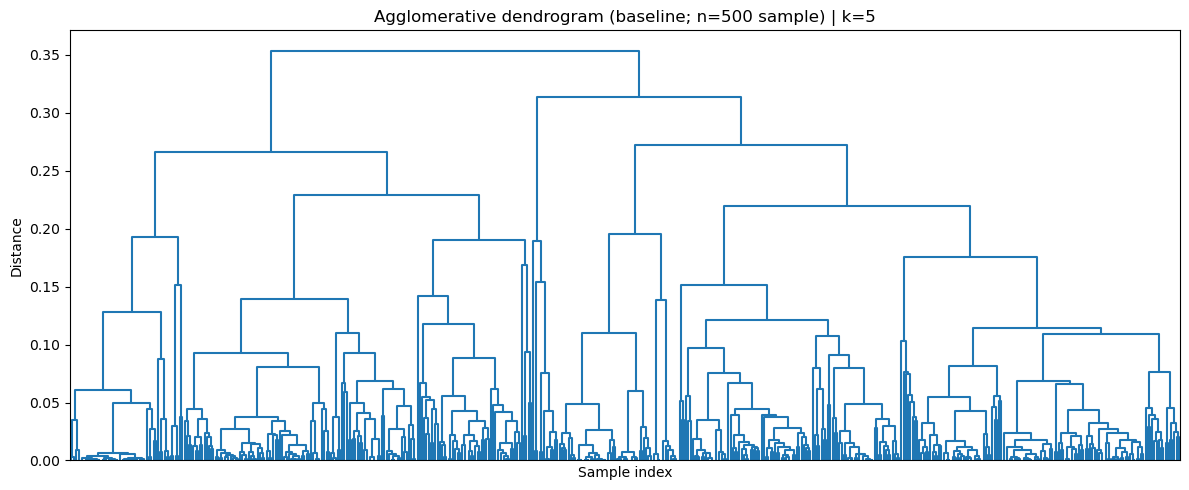

In [65]:
# ---------------------------------------------------------------------------
# 7. Baseline clustering (NO outlier removal): choose K, plot dendrogram, assign labels
# ---------------------------------------------------------------------------
# We already computed silhouette (k=2..8) in Section 6. Here we set a baseline K for
# interpretability and for detecting singleton outliers.
K_BASELINE = 5  # k=2 is too coarse; k=5 matches the classmate example and is more interpretable
candidates["cluster"] = fcluster(linkage_matrix, K_BASELINE, criterion="maxclust")

# Dendrogram (subsample for readability)
n_plot = min(500, len(candidates))
idx_plot = np.random.RandomState(42).choice(len(candidates), n_plot, replace=False)
D_sub = D[np.ix_(idx_plot, idx_plot)]
linkage_sub = linkage(squareform(D_sub, checks=False), method="average")
plt.figure(figsize=(12, 5))
dendrogram(linkage_sub, no_labels=True, color_threshold=0)
plt.title(f"Agglomerative dendrogram (baseline; n={n_plot} sample) | k={K_BASELINE}")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [66]:
# ---------------------------------------------------------------------------
# 8. Baseline singleton inspection (based on Section 7 baseline labels)
# ---------------------------------------------------------------------------
baseline_sizes = candidates["cluster"].value_counts().sort_index()
print("Baseline cluster sizes (number of candidates per cluster):")
print(baseline_sizes)

singleton_clusters = baseline_sizes[baseline_sizes == 1].index.tolist()
print("\nBaseline singleton clusters:", singleton_clusters)

for cid in singleton_clusters:
    print(f"\n=== Details for singleton cluster {cid} ===")
    cols_to_show = ["CANDIDATE_ID"] + retained_numeric + [
        "age", "gender", "ethnicity", "last_year_income", "highest_grade_completed", "c_state"
    ]
    existing_cols = [c for c in cols_to_show if c in candidates.columns]
    display(candidates.loc[candidates["cluster"] == cid, existing_cols])

Baseline cluster sizes (number of candidates per cluster):
cluster
1      76
2    2088
3     415
4    1118
5       1
Name: count, dtype: int64

Baseline singleton clusters: [5]

=== Details for singleton cluster 5 ===


,CANDIDATE_ID,avg_score,pass_rate,college_ready_rate,avg_retakes,credential_earned,pct_online,used_ged_ready,has_prep_center,age,gender,ethnicity,last_year_income,highest_grade_completed,c_state
2702,6590053,170.307692,1.0,0.692308,18.5,1,0.0,1,1,20,1,3,0,6,UNKNOWN


Baseline singleton clusters: [5]
Outlier candidate IDs removed: [6590053]
Candidates before: 3698 after removal: 3697
Filtered cluster matrix: 3697 x 8

Silhouette results on filtered set (k=2..8):
 k  avg_silhouette
 2        0.428861
 3        0.391542
 4        0.430324
 5        0.406475
 6        0.460231
 7        0.516026
 8        0.504678
Selected best_k (max silhouette): 7


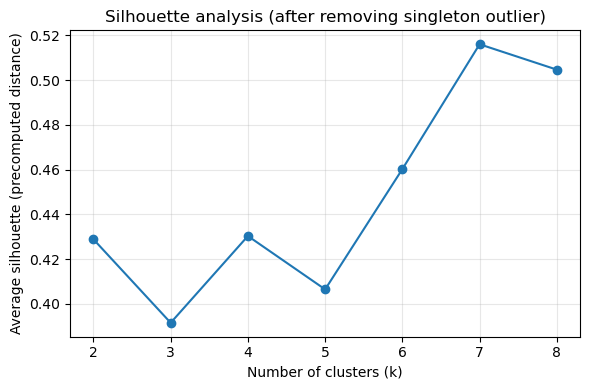

In [71]:
# ---------------------------------------------------------------------------
# 10. Remove singleton outlier candidate(s), then pick the best k (k=2..8)
#     using the SAME retained features and preprocessing rules
# ---------------------------------------------------------------------------

# 10.1 Identify singleton cluster(s) from Section 8, then remove those candidate(s)
baseline_sizes = candidates["cluster"].value_counts().sort_index()
singleton_clusters = baseline_sizes[baseline_sizes == 1].index.tolist()
outlier_ids = candidates.loc[candidates["cluster"].isin(singleton_clusters), "CANDIDATE_ID"].tolist()

print("Baseline singleton clusters:", singleton_clusters)
print("Outlier candidate IDs removed:", outlier_ids)

candidates_filtered = candidates[~candidates["CANDIDATE_ID"].isin(outlier_ids)].copy()
print("Candidates before:", len(candidates), "after removal:", len(candidates_filtered))

# 10.2 Rebuild the clustering matrix on the filtered set
# NOTE: We reuse retained_numeric from Section 4.
retained_numeric_filtered = retained_numeric

binary_candidates = [
    "used_ged_ready", "studied_for_ged", "has_prep_center", "credential_earned",
    "study_helpful_adult_education_class", "study_books", "study_helpful_online_course_video_study_materials",
]
binary_cols = [c for c in binary_candidates if c in retained_numeric_filtered]
continuous_cols = [c for c in retained_numeric_filtered if c not in binary_cols]
subject_score_cols = ["score_math", "score_science", "score_reasoning", "score_social_studies"]

cluster_df_filtered = candidates_filtered[["CANDIDATE_ID"] + retained_numeric_filtered].copy()

# Continuous: z-score; non-subject NA -> 0; subject scores keep NA
for col in continuous_cols:
    vals = cluster_df_filtered[col].dropna()
    if len(vals) > 0 and vals.std() > 0:
        cluster_df_filtered[col] = (cluster_df_filtered[col] - vals.mean()) / vals.std()
for col in continuous_cols:
    if col not in subject_score_cols:
        cluster_df_filtered[col] = cluster_df_filtered[col].fillna(0)

# Binary: keep 0/1
for col in binary_cols:
    cluster_df_filtered[col] = cluster_df_filtered[col].fillna(0).astype(int)

print("Filtered cluster matrix:", cluster_df_filtered.shape[0], "x", len(retained_numeric_filtered))

# 10.3 Gower distance + silhouette for k=2..8
X_cluster_filtered = cluster_df_filtered[retained_numeric_filtered].copy()
D_filtered = gower.gower_matrix(X_cluster_filtered)
linkage_filtered = linkage(squareform(D_filtered, checks=False), method="average")

sil_results_filtered = []
for k in range(2, 9):
    labels_k = fcluster(linkage_filtered, k, criterion="maxclust")
    sil_results_filtered.append({"k": k, "avg_silhouette": silhouette_score(D_filtered, labels_k, metric="precomputed")})

sil_df_filtered = pd.DataFrame(sil_results_filtered)
best_k = int(sil_df_filtered.loc[sil_df_filtered["avg_silhouette"].idxmax(), "k"])

print("\nSilhouette results on filtered set (k=2..8):")
print(sil_df_filtered.to_string(index=False))
print("Selected best_k (max silhouette):", best_k)

plt.figure(figsize=(6, 4))
plt.plot(sil_df_filtered["k"], sil_df_filtered["avg_silhouette"], marker="o")
plt.title("Silhouette analysis (after removing singleton outlier)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette (precomputed distance)")
plt.xticks(list(range(2, 9)))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Using SELECTED_K: 7

Final cluster sizes:
cluster
1    415
2    696
3    422
4    953
5    714
6     24
7    473
Name: count, dtype: int64


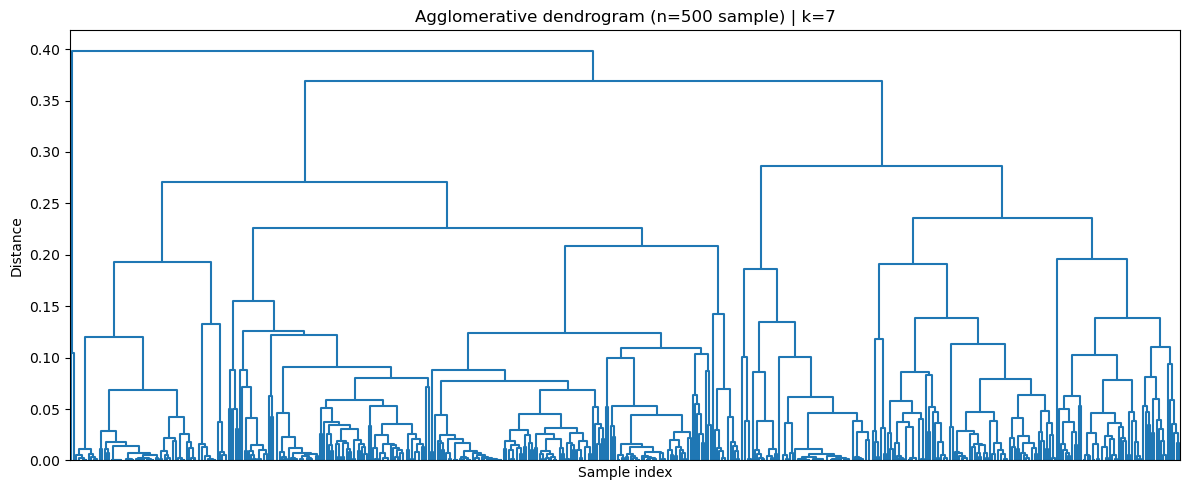

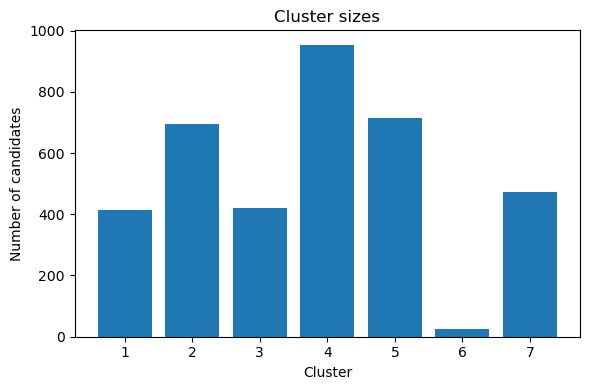

--- Performance (clustering features) ---
           N  Avg_Score Pass_Rate College_Ready Credential_Earned  \
cluster                                                             
1        415   157.1162     93.8%         19.9%            100.0%   
2        696   156.2565     89.1%         20.4%            100.0%   
3        422   154.5590     87.3%         14.6%            100.0%   
4        953   146.8245     53.7%          7.4%              0.0%   
5        714   145.4800     52.5%          4.8%              0.0%   
6         24   168.9375     96.5%         74.3%              0.0%   
7        473   143.7273     36.4%          0.3%              0.0%   

         Avg_Retakes Pct_Online Used_GED_Ready Has_Prep_Center  
cluster                                                         
1             0.1024       0.0%           0.0%           12.3%  
2             1.2942      16.0%         100.0%            0.0%  
3             1.4765       9.8%         100.0%          100.0%  
4          

In [68]:
# ---------------------------------------------------------------------------
# 11. Final clustering with selected k (best silhouette) + plots + post-hoc tables
# ---------------------------------------------------------------------------

SELECTED_K = int(best_k)
print("Using SELECTED_K:", SELECTED_K)

# Assign clusters on the filtered set
candidates_final = candidates_filtered.copy()
candidates_final["cluster"] = fcluster(linkage_filtered, SELECTED_K, criterion="maxclust")

# Save final feature list for downstream steps (e.g., saving outputs)
retained_numeric_final = retained_numeric_filtered

print("\nFinal cluster sizes:")
print(candidates_final["cluster"].value_counts().sort_index())

# --- Plot dendrogram on a sample (readability)
np.random.seed(42)
n_plot = min(500, len(candidates_final))
idx_plot = np.random.choice(len(candidates_final), n_plot, replace=False)
D_sub = D_filtered[np.ix_(idx_plot, idx_plot)]
linkage_sub = linkage(squareform(D_sub, checks=False), method="average")

plt.figure(figsize=(12, 5))
dendrogram(linkage_sub, no_labels=True, color_threshold=0)
plt.title(f"Agglomerative dendrogram (n={n_plot} sample) | k={SELECTED_K}")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# --- Cluster size bar chart
sizes = candidates_final["cluster"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(sizes.index.astype(str), sizes.values)
plt.title("Cluster sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of candidates")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Post-hoc summary tables (same structure as Section 8, based on candidates_final)
# ---------------------------------------------------------------------------

def fmt_pct(x: float) -> str:
    return f"{x:.1%}"

print("--- Performance (clustering features) ---")
t1 = candidates_final.groupby("cluster").agg(
    N=("CANDIDATE_ID", "count"),
    Avg_Score=("avg_score", "mean"),
    Pass_Rate=("pass_rate", "mean"),
    College_Ready=("college_ready_rate", "mean"),
    Credential_Earned=("credential_earned", "mean"),
    Avg_Retakes=("avg_retakes", "mean"),
    Pct_Online=("pct_online", "mean"),
    Used_GED_Ready=("used_ged_ready", "mean"),
    Has_Prep_Center=("has_prep_center", "mean"),
).round(4)

# Format rates for readability
for c in ["Pass_Rate", "College_Ready", "Credential_Earned", "Pct_Online", "Used_GED_Ready", "Has_Prep_Center"]:
    t1[c] = t1[c].apply(fmt_pct)
print(t1)

# Subject scores (if present)
subj_cols = [c for c in ["score_math", "score_science", "score_reasoning", "score_social_studies"] if c in candidates_final.columns]
if subj_cols:
    print("\n--- Subject scores ---")
    t2 = candidates_final.groupby("cluster")[subj_cols].mean().round(1)
    print(t2)

# Preparation (post-hoc)
prep_cols = [c for c in [
    "studied_for_ged",
    "study_helpful_adult_education_class",
    "study_books",
    "study_helpful_online_course_video_study_materials",
] if c in candidates_final.columns]
if prep_cols:
    print("\n--- Preparation behaviors (post-hoc) ---")
    t3 = candidates_final.groupby("cluster")[prep_cols].mean().round(4)
    for c in prep_cols:
        t3[c] = t3[c].apply(fmt_pct)
    print(t3)

# Demographics (post-hoc)
print("\n--- Demographics (post-hoc) ---")
demo = candidates_final.groupby("cluster").agg(
    Avg_Age=("age", "mean"),
    Male=("gender", lambda x: (x == 1).mean()),
    Female=("gender", lambda x: (x == 2).mean()),
    Black=("african_american", lambda x: (x == 1).mean()),
    White=("white", lambda x: (x == 1).mean()),
    Hispanic=("ethnicity", lambda x: (x == 2).mean()),
).round(4)
for c in ["Male", "Female", "Black", "White", "Hispanic"]:
    demo[c] = demo[c].apply(fmt_pct)
print(demo)


In [69]:
# ---------------------------------------------------------------------------
# 12. Cluster × Feature contribution matrix 
# ---------------------------------------------------------------------------
# Output (as requested):
# - Contribution rate matrix (%) only (rows = clusters, columns = features; each row sums to 100%)
# - A heatmap visualization of the contribution rates
# - A compact summary table: Top features per cluster with contribution %
#
# Notes:
# - Continuous features: use z-score, then impact = cluster mean z
# - Binary features: impact = standardized proportion difference vs overall proportion
# - Contribution rate per cluster = |impact| / sum(|impact|) across features in that cluster

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _is_binary_series(s: pd.Series) -> bool:
    x = s.dropna().unique()
    if len(x) == 0:
        return False
    return set(x).issubset({0, 1})


cluster_col = "cluster"
if cluster_col not in candidates_final.columns:
    raise KeyError("Expected 'candidates_final' with a 'cluster' column. Run Section 11 first.")

features = list(retained_numeric_final)
clusters = sorted(candidates_final[cluster_col].dropna().unique())

# Split features
binary_feats = [f for f in features if _is_binary_series(candidates_final[f])]
cont_feats = [f for f in features if f not in binary_feats]

# --- Continuous: z-score (same idea as clustering matrix)
Z = pd.DataFrame(index=candidates_final.index)
if cont_feats:
    mu = candidates_final[cont_feats].mean(skipna=True)
    sd = candidates_final[cont_feats].std(skipna=True, ddof=0).replace(0, np.nan)
    Z[cont_feats] = (candidates_final[cont_feats] - mu) / sd

# --- Binary: keep as 0/1
if binary_feats:
    Z[binary_feats] = candidates_final[binary_feats].astype(float)

# --- Cluster centroids (means)
centroids = Z.groupby(candidates_final[cluster_col]).mean(numeric_only=True)
centroids = centroids.reindex(clusters)

# --- Impact definition (kept internally; we do not print signed impact)
impact = pd.DataFrame(index=clusters, columns=features, dtype=float)

for f in cont_feats:
    impact[f] = centroids[f]

for f in binary_feats:
    p_overall = float(Z[f].mean(skipna=True))
    denom = np.sqrt(p_overall * (1 - p_overall))
    delta = centroids[f] - p_overall
    impact[f] = 0.0 if (denom == 0 or np.isnan(denom)) else (delta / denom)

# --- Contribution rate (%), per cluster row sums to 100%
abs_imp = impact.abs()
row_sums = abs_imp.sum(axis=1).replace(0, np.nan)
contrib_rate = abs_imp.div(row_sums, axis=0) * 100
contrib_out = contrib_rate.round(1)

print("\n=== Cluster × Feature contribution rate matrix (%, each row sums to 100) ===")
print(contrib_out)


# --- Text summary: Top-K features per cluster
TOP_K = 5
print("\n=== Top features per cluster (by contribution %) ===")
for c in clusters:
    top = contrib_out.loc[c].sort_values(ascending=False).head(TOP_K)
    msg = ", ".join([f"{feat} ({pct:.1f}%)" for feat, pct in top.items()])
    print(f"- Cluster {int(c)}: {msg}")



=== Cluster × Feature contribution rate matrix (%, each row sums to 100) ===
   avg_score  pass_rate  college_ready_rate  avg_retakes  credential_earned  \
1       10.0       11.8                 6.0         11.3               18.9   
2       10.7       12.0                 7.8          8.4               23.1   
3        7.8       11.2                 3.0         12.0               23.4   
4       10.1       11.3                 5.1          1.6               27.1   
5       10.6        9.4                 6.6          2.8               20.5   
6       17.9        8.6                28.6          8.5                8.8   
7       10.3       14.2                 8.1         10.2               14.6   

   pct_online  used_ged_ready  has_prep_center  
1         6.7            27.8              7.5  
2        12.5            11.1             14.2  
3         4.6            11.2             26.9  
4         2.8            18.4             23.6  
5         2.7            14.0             33

In [70]:
# ---------------------------------------------------------------------------
# 13. Export ONE final PDF report (ONLY the requested outputs)
# ---------------------------------------------------------------------------
# This cell generates ONE PDF that contains exactly:
# 1) Introduction (experimental setup; action + purpose)
# 2) Final dendrogram with a horizontal cut line at Using SELECTED_K
# 3) Text block: Using SELECTED_K + Final cluster sizes
# 4) All post-hoc summary outputs (performance, subject, preparation, demographics)
# 5) Cluster × Feature contribution matrix (PCA-like table) + heatmap
# 6) Text block: Top features per cluster (feature + contribution %)
#
# No CSV export here.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform


# -------------------------------
# Helpers (robust PDF rendering)
# -------------------------------

def _mono_text_page(pdf: PdfPages, title: str, text: str, fontsize: int = 10):
    """Write a monospace text page to PDF (reliable; avoids empty table pages)."""
    fig = plt.figure(figsize=(11, 8.5))
    ax = fig.add_subplot(111)
    ax.axis("off")
    ax.set_title(title, fontsize=14, pad=12)
    ax.text(
        0.02,
        0.98,
        text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=fontsize,
        transform=ax.transAxes,
        wrap=True,
    )
    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def _df_to_text(df: pd.DataFrame) -> str:
    """Convert DataFrame to a fixed-width string for PDF."""
    return df.to_string()


def _find_cut_height_for_k_distance(Z: np.ndarray, k: int) -> float:
    """Find a distance threshold t such that fcluster(Z, t, 'distance') yields ~k clusters.

    If an exact threshold does not exist due to tied merge distances, returns the closest match.
    """
    u = np.unique(Z[:, 2])
    u.sort()
    if len(u) == 0:
        return 0.0

    # Candidate thresholds: midpoints between distinct distances
    candidates = [float(u[0]) - 1e-6]
    for a, b in zip(u[:-1], u[1:]):
        if b > a:
            candidates.append(float((a + b) / 2.0))
    candidates.append(float(u[-1]) + 1e-6)

    best_t = candidates[0]
    best_gap = 1e9

    for t in candidates:
        labels = fcluster(Z, t, criterion="distance")
        n = int(pd.Series(labels).nunique())
        gap = abs(n - int(k))
        if gap < best_gap:
            best_gap = gap
            best_t = t
        if n == int(k):
            return t

    return best_t


def _is_binary_series(s: pd.Series) -> bool:
    x = s.dropna().unique()
    if len(x) == 0:
        return False
    return set(x).issubset({0, 1})


# -------------------------------
# Inputs expected from Section 11
# -------------------------------
try:
    SELECTED_K
except NameError as e:
    raise NameError("SELECTED_K is not defined. Run Section 11 first.") from e

if "cluster" not in candidates_final.columns:
    raise KeyError("Expected candidates_final with a 'cluster' column. Run Section 11 first.")

if "D_filtered" not in globals():
    raise NameError("Expected D_filtered (Gower distance matrix). Run Section 10/11 first.")


# -------------------------------
# 1) Introduction text (action + purpose)
# -------------------------------
intro_text = "\n".join(
    [
        "Pipeline overview (action → purpose):",
        "1) Load `5_test_candidate_cleaned_final.csv` and validate key column names (e.g., EXAM_SUBJECT, CREDENTIAL_DATE, SCORE_MISSING) → ensure the Python pipeline matches the R reference inputs.",
        "2) Aggregate exam-attempt rows to one row per `CANDIDATE_ID` (scores, pass>=145, college>=165, avg_retakes formula; subject means only if attempted; missing subjects stay NA) → create a candidate-level clustering dataset.",
        "3) Derive profiling-only fields (e.g., age, census_region, race_category and *_label) → support interpretation tables without affecting clusters.",
        "4) Completeness Stage 1: treat sentinel 0 as missing for demographics; compute completeness across 26 key fields; keep candidates with completeness ≥ 0.70 → remove records with too little usable information.",
        "5) Completeness Stage 2: drop candidates with no demographic identity (no gender AND no race AND no ethnicity) → remove un-profileable cases.",
        "6) Variance filter on numeric clustering columns (relative variance ≥ 0.15; protect `avg_score`) → drop near-constant features with no segmentation power.",
        "7) Correlation filter on retained numeric columns (|r| > 0.80 drop one; protect `avg_score`) → reduce redundancy / multicollinearity.",
        "8) Preprocess for mixed data: continuous vs binary; continuous z-score; non-subject NA → 0, subject NA kept; binary stays 0/1 → align scales while preserving missingness semantics.",
        "9) Compute Gower distance on clustering features only (exclude IDs and all demographic/geography) → measure dissimilarity for mixed types.",
        "10) Run agglomerative hierarchical clustering (average linkage); choose k via silhouette (2..8) and dendrogram → select an interpretable, data-supported partition.",
        "11) Output cluster labels and post-hoc tables (performance, subject, preparation, demographics) → describe cluster profiles after clustering.",
        "12) Scope decisions: do NOT implement DIANA; do NOT use study/reason/enrollment as clustering features (profiling only) → avoid mixing survey behavior fields into segmentation.",
    ]
)


# -------------------------------
# 2) Dendrogram (with cut line at k)
# -------------------------------
np.random.seed(42)
n_plot = min(500, len(candidates_final))
idx_plot = np.random.choice(len(candidates_final), n_plot, replace=False)
D_sub = D_filtered[np.ix_(idx_plot, idx_plot)]
linkage_sub = linkage(squareform(D_sub, checks=False), method="average")
cut_h = _find_cut_height_for_k_distance(linkage_sub, int(SELECTED_K))


# -------------------------------
# 3) Using SELECTED_K + cluster sizes (exact text block)
# -------------------------------
sizes = candidates_final["cluster"].value_counts().sort_index()
final_k_text = (
    f"Using SELECTED_K: {int(SELECTED_K)}\n\n"
    f"Final cluster sizes:\n{sizes.to_string()}\n\n"
    f"Name: count, dtype: int64"
)


# -------------------------------
# 4) Post-hoc summary tables (same as Section 11)
# -------------------------------

def fmt_pct(x: float) -> str:
    return f"{x:.1%}"

perf = candidates_final.groupby("cluster").agg(
    N=("CANDIDATE_ID", "count"),
    Avg_Score=("avg_score", "mean"),
    Pass_Rate=("pass_rate", "mean"),
    College_Ready=("college_ready_rate", "mean"),
    Credential_Earned=("credential_earned", "mean"),
    Avg_Retakes=("avg_retakes", "mean"),
    Pct_Online=("pct_online", "mean"),
    Used_GED_Ready=("used_ged_ready", "mean"),
    Has_Prep_Center=("has_prep_center", "mean"),
).round(4)
for c in ["Pass_Rate", "College_Ready", "Credential_Earned", "Pct_Online", "Used_GED_Ready", "Has_Prep_Center"]:
    perf[c] = perf[c].apply(fmt_pct)

subj_cols = [c for c in ["score_math", "score_science", "score_reasoning", "score_social_studies"] if c in candidates_final.columns]
subj = candidates_final.groupby("cluster")[subj_cols].mean().round(1) if subj_cols else None

prep_cols = [c for c in [
    "studied_for_ged",
    "study_helpful_adult_education_class",
    "study_books",
    "study_helpful_online_course_video_study_materials",
] if c in candidates_final.columns]
prep = candidates_final.groupby("cluster")[prep_cols].mean().round(4) if prep_cols else None
if prep is not None:
    for c in prep_cols:
        prep[c] = prep[c].apply(fmt_pct)

if all(col in candidates_final.columns for col in ["age", "gender", "african_american", "white", "ethnicity"]):
    demo = candidates_final.groupby("cluster").agg(
        Avg_Age=("age", "mean"),
        Male=("gender", lambda x: (x == 1).mean()),
        Female=("gender", lambda x: (x == 2).mean()),
        Black=("african_american", lambda x: (x == 1).mean()),
        White=("white", lambda x: (x == 1).mean()),
        Hispanic=("ethnicity", lambda x: (x == 2).mean()),
    ).round(4)
    for c in ["Male", "Female", "Black", "White", "Hispanic"]:
        demo[c] = demo[c].apply(fmt_pct)
else:
    demo = None


# -------------------------------
# 5) Contribution matrix (PCA-like) + heatmap + Top-features text
# -------------------------------
features = list(retained_numeric_final)
clusters = sorted(candidates_final["cluster"].dropna().unique())

binary_feats = [f for f in features if _is_binary_series(candidates_final[f])]
cont_feats = [f for f in features if f not in binary_feats]

Z = pd.DataFrame(index=candidates_final.index)
if cont_feats:
    mu = candidates_final[cont_feats].mean(skipna=True)
    sd = candidates_final[cont_feats].std(skipna=True, ddof=0).replace(0, np.nan)
    Z[cont_feats] = (candidates_final[cont_feats] - mu) / sd
if binary_feats:
    Z[binary_feats] = candidates_final[binary_feats].astype(float)

centroids = Z.groupby(candidates_final["cluster"]).mean(numeric_only=True).reindex(clusters)
impact = pd.DataFrame(index=clusters, columns=features, dtype=float)

for f in cont_feats:
    impact[f] = centroids[f]
for f in binary_feats:
    p_overall = float(Z[f].mean(skipna=True))
    denom = np.sqrt(p_overall * (1 - p_overall))
    delta = centroids[f] - p_overall
    impact[f] = 0.0 if (denom == 0 or np.isnan(denom)) else (delta / denom)

abs_imp = impact.abs()
row_sums = abs_imp.sum(axis=1).replace(0, np.nan)
contrib_out = (abs_imp.div(row_sums, axis=0) * 100).round(1)

TOP_K = 5
top_lines = ["=== Top features per cluster (by contribution %) ==="]
for c in clusters:
    top = contrib_out.loc[c].sort_values(ascending=False).head(TOP_K)
    msg = ", ".join([f"{feat} ({pct:.1f}%)" for feat, pct in top.items()])
    top_lines.append(f"- Cluster {int(c)}: {msg}")


# -------------------------------
# Write ONE PDF
# -------------------------------
pdf_path = "/Users/ankit/Downloads/EDA-Team assignment/clustering_report_final.pdf"

with PdfPages(pdf_path) as pdf:
    # 1) Introduction
    _mono_text_page(pdf, "Introduction — experimental setup", intro_text, fontsize=10)

    # 2) Dendrogram with cut line
    fig = plt.figure(figsize=(11, 8.5))
    ax = fig.add_subplot(111)
    dendrogram(
        linkage_sub,
        no_labels=True,
        color_threshold=cut_h,
        truncate_mode="level",
        p=30,
    )
    ax.axhline(y=cut_h, color="red", linestyle="--", linewidth=2)
    ax.set_title(f"Agglomerative dendrogram (n={n_plot} sample) | k={int(SELECTED_K)}")
    ax.set_xlabel("Sample index (truncated)")
    ax.set_ylabel("Distance")
    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # 3) K + sizes
    _mono_text_page(pdf, "Using SELECTED_K and final cluster sizes", final_k_text, fontsize=12)

    # 4) Post-hoc summaries
    _mono_text_page(pdf, "Post-hoc summary — Performance (clustering features)", _df_to_text(perf), fontsize=10)
    if subj is not None:
        _mono_text_page(pdf, "Post-hoc summary — Subject scores", _df_to_text(subj), fontsize=10)
    if prep is not None:
        _mono_text_page(pdf, "Post-hoc summary — Preparation behaviors", _df_to_text(prep), fontsize=10)
    if demo is not None:
        _mono_text_page(pdf, "Post-hoc summary — Demographics", _df_to_text(demo), fontsize=10)

    # 5) Contribution matrix
    _mono_text_page(pdf, "Cluster × Feature contribution matrix (%)", _df_to_text(contrib_out), fontsize=10)

    fig = plt.figure(figsize=(11, 8.5))
    ax = fig.add_subplot(111)
    im = ax.imshow(contrib_out.values, aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=ax, label="Contribution rate (%)")
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, rotation=45, ha="right")
    ax.set_yticks(range(len(clusters)))
    ax.set_yticklabels([str(c) for c in clusters])
    ax.set_title("Cluster × Feature contribution rates (heatmap)")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Cluster")
    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # 6) Top features text
    _mono_text_page(pdf, "Top features per cluster (by contribution %)", "\n".join(top_lines), fontsize=12)

print(f"Saved ONE PDF report: {pdf_path}")


Saved ONE PDF report: /Users/ankit/Downloads/EDA-Team assignment/clustering_report_final.pdf
